In [56]:
from pathlib import Path

import pandas as pd
import sys
sys.path.insert(0, '.')
from lib.classes.Satellite import Satellite, InstantSatellite
from lib.classes.Point import Point
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

RANGE=28000
MIN_NEIGHBOR=0
MAX_NEIGHBOR=0

def load_data(filepath: str | Path, separator: str = ",", header: int | None = None) -> pd.DataFrame:
    """Load raw data from a CSV file.

    Args:
        filepath: Path to the CSV file (str or Path object).
        separator: Column delimiter used in the CSV file. Defaults to ','.
        header: Row number to use as column names.
                None means no header row. Defaults to None.

    Returns:
        Raw DataFrame loaded from the CSV file.

    Raises:
        FileNotFoundError: If the file does not exist at the given path.
        ValueError: If the file extension is not '.csv'.
    """
    filepath = Path(filepath)

    if not filepath.exists():
        raise FileNotFoundError(f"File not found: '{filepath}'")

    if filepath.suffix.lower() != ".csv":
        raise ValueError(
            f"Expected a '.csv' file, got '{filepath.suffix}' instead."
        )

    return pd.read_csv(filepath, sep=separator, header=header)

def struct_data(df: pd.DataFrame) -> list[Satellite]:

    # Create columns label
    df.columns = [f"t{i}" for i in range(len(df.columns))]

    satellites = []

    import time
    start = time.perf_counter()   

    # Satellite coordinate data processing
    for i in range(0, len(df), 3):
        coords = df.iloc[i:i+3].values
        sat_id = int(i/3)
        satellite = Satellite(sat_id, f"SAT-{sat_id:03d}")

        for j in range(coords.shape[1]):
            satellite.add_instant(Point(coords[0, j], coords[1, j], coords[2, j]))

        satellites.append(satellite)

    # Satellite neighbors processing
    for index, sat in enumerate(satellites):
        for other_sat in satellites[index+1:]:
            for i in range(len(sat.list_coordinates)):
                in_range = sat.list_coordinates[i].point.in_range( other_sat.list_coordinates[i].point, RANGE)
                if in_range:
                    sat.list_coordinates[i].add_neighbor(other_sat)
                    other_sat.list_coordinates[i].add_neighbor(sat)
    end = time.perf_counter()

    print(len(satellites))
    print(f"Temps écoulé : {end - start} secondes")

    return satellites

def show_data(satellites: list[Satellite], number: int) -> None:
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    for sat in satellites[:number]:
        xs = np.array([instant.point.x for instant in sat.list_coordinates])
        ys = np.array([instant.point.y for instant in sat.list_coordinates])
        zs = np.array([instant.point.z for instant in sat.list_coordinates])

        axes.plot(xs, ys, zs, label=f"Sat {sat.name}")

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title("Trajectoires des Satellites")
    plt.show()


def show_instant_nodes(satellites: list[Satellite], instant: int) -> None:
    plt.show()
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    # Create Nodes
    for sat in satellites:
        point = sat.list_coordinates[instant].point    
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            c='blue',
            label='Satellites')

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()

def show_instant_nodes_edges(satellites: list[Satellite], instant: int) -> None:
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    # Create Nodes and edges
    for sat in satellites:
        # Nodes
        point = sat.list_coordinates[instant].point    
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            #c='blue',
            label='Satellites')

        # Edges
        for neighbor in sat.list_coordinates[instant].neighbors:
            neighbor_point = neighbor.list_coordinates[instant].point
            axes.plot(
                [point.x, neighbor_point.x],
                [point.y, neighbor_point.y],
                [point.z, neighbor_point.z],
                'r-',
                alpha=0.1,
                linewidth=1
            )


    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()

def show_instant_nodes_neighbor(satellites: list[Satellite], instant: int, label: bool = True) -> None:
    fig = plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")


    densities = np.array([
        len(sat.list_coordinates[instant].neighbors)
        for sat in satellites
    ])

    norm = plt.Normalize(vmin=densities.min(), vmax=densities.max())
    colormap = cm.viridis

    # Create Nodes and edges
    for sat, density in zip(satellites, densities):
        # Nodes
        color = (255/255, 0/255, 0/255, 1.0) if density == 0 else colormap(norm(density)) 
        point = sat.list_coordinates[instant].point
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            color=color,
            label='Satellites')
        
        if label:
            axes.text(
                x=point.x,
                y=point.y,
                z=point.z,
                s=sat.name,
                fontsize=8,
                color='black',
                ha='right',
                va='bottom')

        # Edges
        for neighbor in sat.list_coordinates[instant].neighbors:
            neighbor_point = neighbor.list_coordinates[instant].point
            axes.plot(
                [point.x, neighbor_point.x],
                [point.y, neighbor_point.y],
                [point.z, neighbor_point.z],
                'r-',
                alpha=0.1,
                linewidth=1
            )

    scalar_mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
    scalar_mappable.set_array(densities)
    fig.colorbar(scalar_mappable, ax=axes, label="Nombre de voisins", shrink=0.5)

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()


In [57]:
data = load_data("./traces.csv")
print(data[:10])
satellites = struct_data(data)

           0             1             2             3             4     \
0 -4.850747e+05 -4.937755e+05 -5.024536e+05 -5.111086e+05 -5.197401e+05   
1 -7.066530e+05 -7.201117e+05 -7.335372e+05 -7.469290e+05 -7.602864e+05   
2 -2.026363e+06 -2.019625e+06 -2.012795e+06 -2.005871e+06 -1.998855e+06   
3 -4.167305e+05 -4.253905e+05 -4.340304e+05 -4.426496e+05 -4.512477e+05   
4 -7.114496e+05 -7.251144e+05 -7.387446e+05 -7.523398e+05 -7.658991e+05   
5 -2.013985e+06 -2.007244e+06 -2.000408e+06 -1.993476e+06 -1.986450e+06   
6 -4.839084e+05 -4.922692e+05 -5.006077e+05 -5.089237e+05 -5.172168e+05   
7 -7.608448e+05 -7.742544e+05 -7.876291e+05 -8.009682e+05 -8.142713e+05   
8 -2.023770e+06 -2.016739e+06 -2.009618e+06 -2.002406e+06 -1.995103e+06   
9 -3.527034e+05 -3.616050e+05 -3.704891e+05 -3.793552e+05 -3.882029e+05   

           5             6             7             8             9     ...  \
0 -5.283476e+05 -5.369309e+05 -5.454894e+05 -5.540229e+05 -5.625310e+05  ...   
1 -7.736088e+0

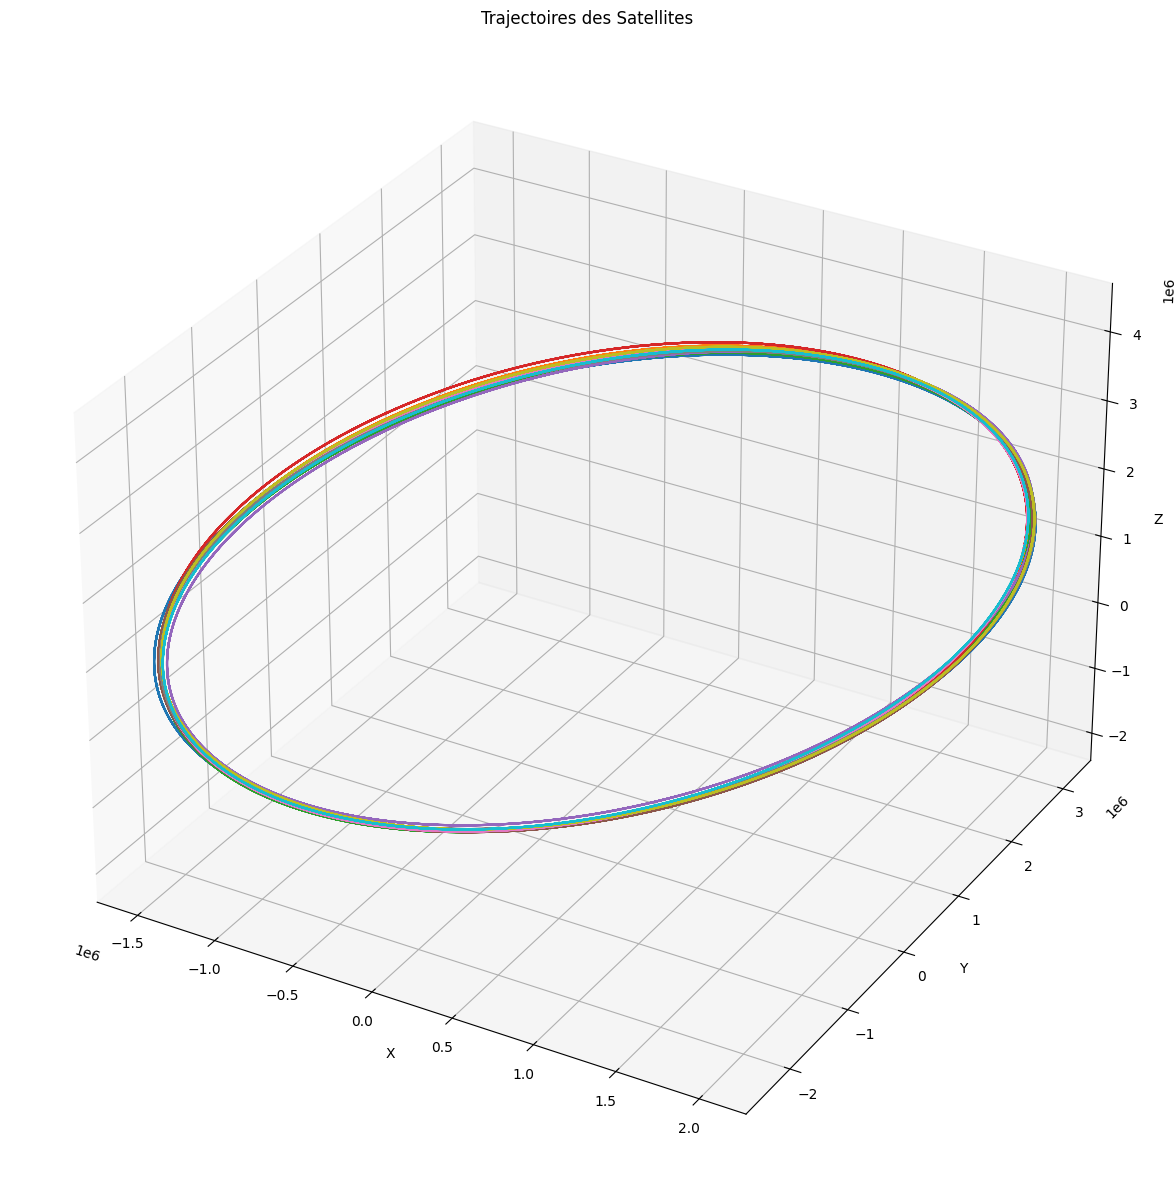

In [58]:
show_data(satellites, 10)

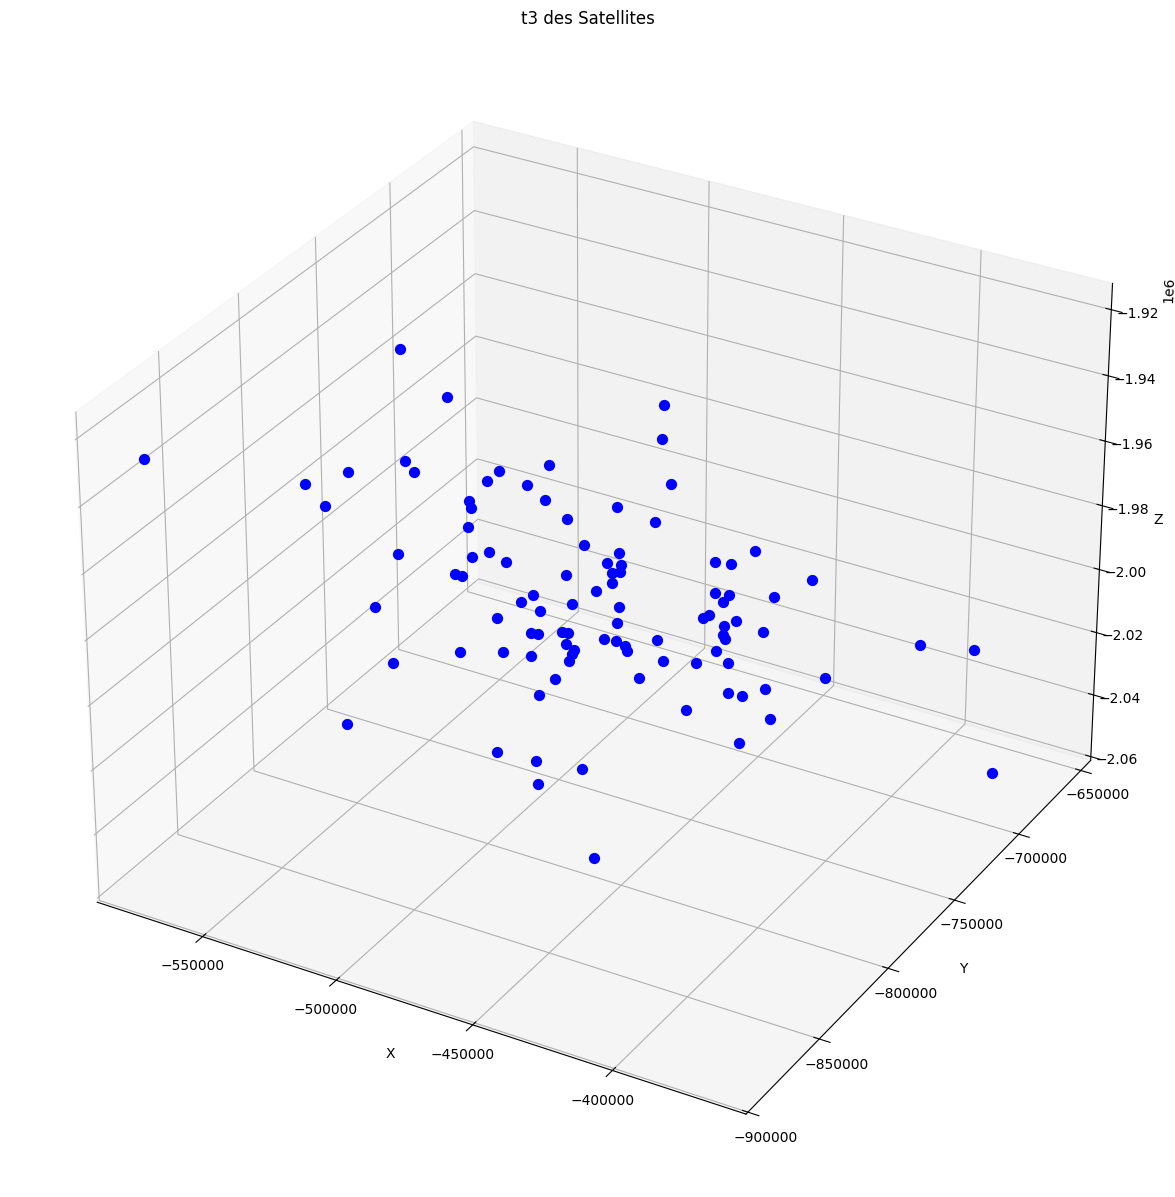

In [59]:
show_instant_nodes(satellites, 3)

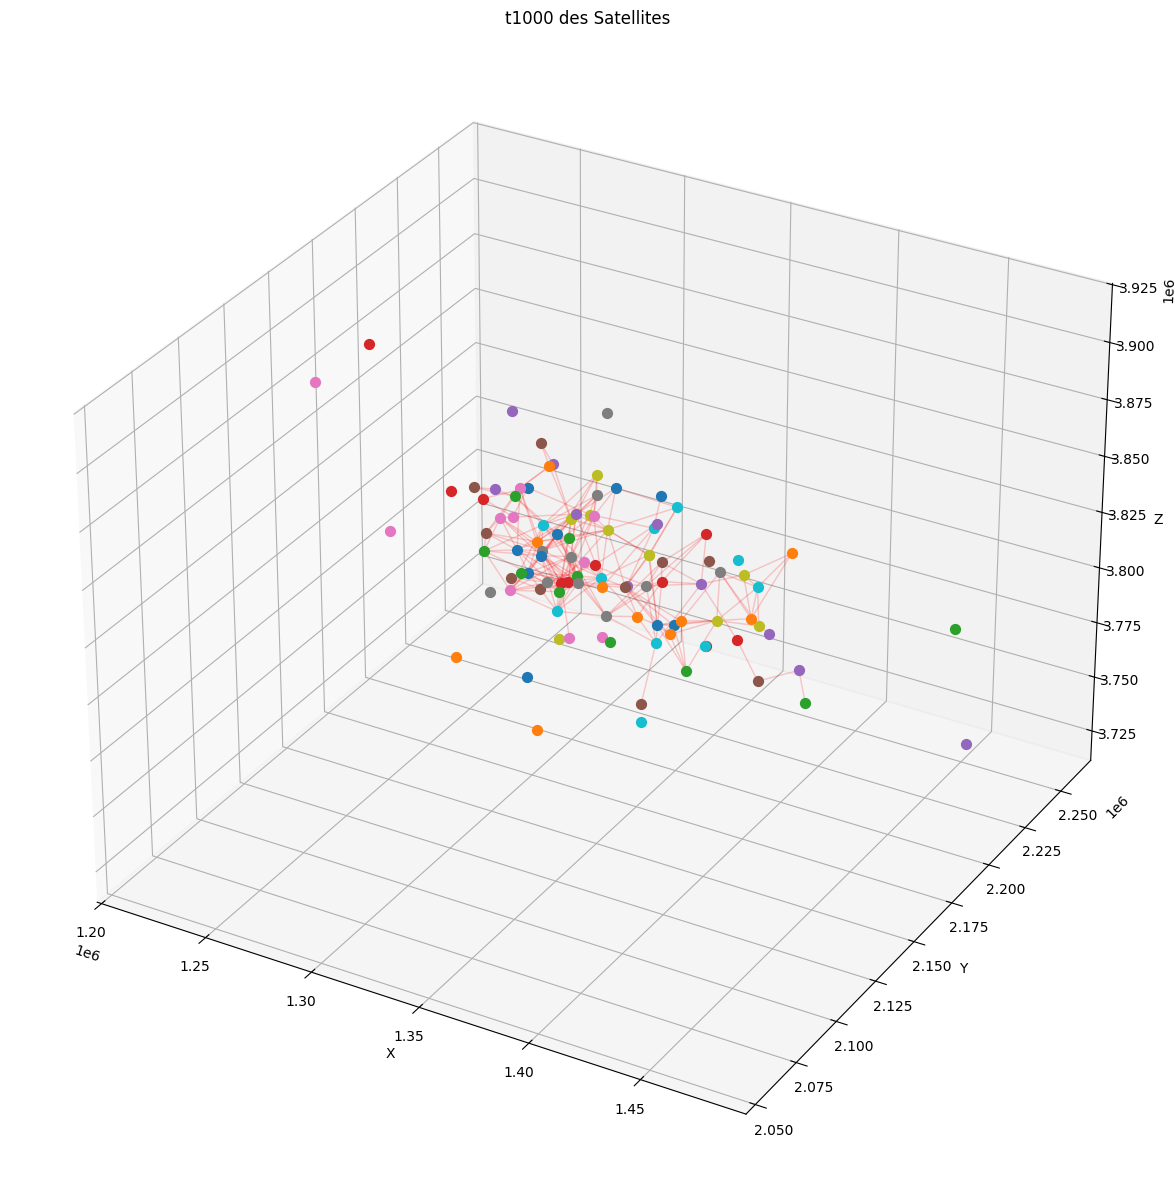

In [60]:
show_instant_nodes_edges(satellites, 1000)

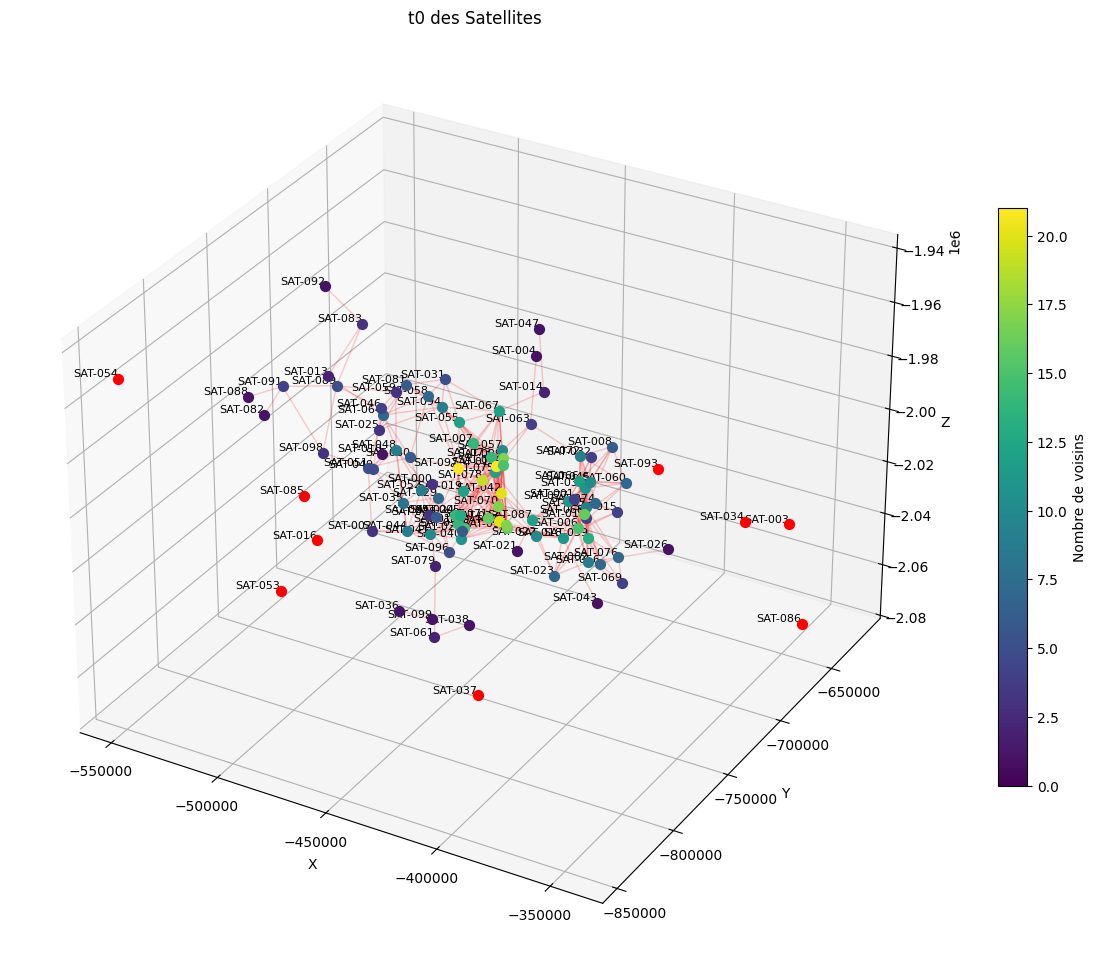

In [61]:
show_instant_nodes_neighbor(satellites=satellites, instant=0, label=True)


In [62]:
from lib.classes.NetworkSimulation import NetworkSimulation, PDU, FloodingRouter

list_satellites = satellites 
nb_instants = len(satellites[0].list_coordinates)

# Tuple description
# (Instant index of PDU, PDU)
example_scenario = [
    (0, PDU(1, list_satellites[0].name, list_satellites[-1].name)),
    (1, PDU(2, list_satellites[0].name, list_satellites[-1].name)),
    (2, PDU(3, list_satellites[0].name, list_satellites[-1].name)),
]

simulation = NetworkSimulation(satellites, FloodingRouter, example_scenario)
print(f"At time {simulation.current_index}, does {list_satellites[0].name} have messages to send ? {simulation.routers[list_satellites[0].name].any_messages_to_send()}")
simulation.next()
print(f"At time {simulation.current_index}, does {list_satellites[0].name} have messages to send ? {simulation.routers[list_satellites[0].name].any_messages_to_send()}")

def messages_received_of_dest():
    return simulation.routers[list_satellites[-1].name].pdus_where_this_router_is_the_destination

while len(messages_received_of_dest()) < len(example_scenario) and simulation.current_index < nb_instants:
    simulation.next()

print(f"At time {simulation.current_index}, {list_satellites[-1].name} has fully received {len(messages_received_of_dest())} messages")

if messages_received_of_dest():
    print("Traces of each messages")
    for pdu in messages_received_of_dest():
        print(pdu)

At time 0, does SAT-000 have messages to send ? False
At time 1, does SAT-000 have messages to send ? True
At time 10000, SAT-099 has fully received 0 messages


In [63]:
def count_unique_edges(sats, i):
    edge_set = set()
    for sat in sats:
        for neighbor in sat.list_coordinates[i].neighbors:
            lower, upper = (sat.name, neighbor.name) if sat.name < neighbor.name else (neighbor.name, sat.name)
            edge_set.add(f"{lower}-{upper}")
    return len(edge_set)
ue = count_unique_edges(satellites, 0)
ue

369

In [64]:
def degree_distribution(sats, i):
    distribution = {}
    for sat in sats:
        deg = len(sat.list_coordinates[i].neighbors)
        if deg in distribution:
            distribution[deg] += 1
        else:
            distribution[deg] = 1
    return dict(sorted(distribution.items()))
d = degree_distribution(satellites, 0)
print(sum(d.values()))
d

100


{0: 9,
 1: 12,
 2: 4,
 3: 7,
 4: 8,
 5: 5,
 6: 5,
 7: 8,
 8: 1,
 9: 7,
 10: 4,
 11: 4,
 12: 6,
 13: 2,
 14: 4,
 15: 3,
 16: 3,
 17: 3,
 19: 1,
 20: 2,
 21: 2}

In [65]:
def average_degree(sats, i, distribution_i = None):
    distrib = distribution_i if distribution_i is not None else degree_distribution(sats, i)
    return sum([deg * nb_sat for deg, nb_sat in distrib.items()]) / sum(distrib.values())
average_degree(satellites, 0, d) # d a déjà été défini avant

7.38

In [66]:
def max_edges_possible(sats):
    n = len(sats)
    return n*(n-1)/2
max_edges_possible(satellites)

4950.0

In [67]:
def density(sats, i, nb_unique_edges = None, max_edges = None):
    nb_l = nb_unique_edges if nb_unique_edges is not None else count_unique_edges(sats, i)
    max_l = max_edges if max_edges is not None else max_edges_possible(sats)
    return nb_l / max_l
density(satellites, 0, ue)

0.07454545454545454

In [68]:
def adjacency_matrix(sats, i):
    names = [sat.name for sat in sats]
    matrix = pd.DataFrame(0, index=names, columns=names)
    for sat in sats:
        for neighbor in sat.list_coordinates[i].neighbors:
            matrix.loc[sat.name, neighbor.name] = 1
    return matrix
adjacency_matrix(satellites, 0)

,SAT-000,SAT-001,SAT-002,SAT-003,SAT-004,SAT-005,SAT-006,SAT-007,SAT-008,SAT-009,...,SAT-090,SAT-091,SAT-092,SAT-093,SAT-094,SAT-095,SAT-096,SAT-097,SAT-098,SAT-099
SAT-000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
SAT-001,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAT-095,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-097,0,0,0,0,0,1,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0
SAT-098,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [69]:
def weight_matrix(sats, i):
    names = [sat.name for sat in sats]
    matrix = pd.DataFrame(0, index=names, columns=names)
    for sat in sats:
        for neighbor in sat.list_coordinates[i].neighbors:
            matrix.loc[sat.name, neighbor.name] = 10
    return matrix
weight_matrix(satellites, 0)

,SAT-000,SAT-001,SAT-002,SAT-003,SAT-004,SAT-005,SAT-006,SAT-007,SAT-008,SAT-009,...,SAT-090,SAT-091,SAT-092,SAT-093,SAT-094,SAT-095,SAT-096,SAT-097,SAT-098,SAT-099
SAT-000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,10,0,0,0,0
SAT-001,0,0,0,0,0,0,10,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAT-095,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-097,0,0,0,0,0,10,0,10,0,10,...,0,0,0,0,10,0,0,0,0,0
SAT-098,0,0,0,0,0,0,0,0,0,0,...,0,10,0,0,0,0,0,0,0,0


In [70]:
def dijkstra(sats, i, start_sat_name, weight_mat = None):
    sats_dict = {sat.name: sat for sat in sats}
    w_matrix = weight_mat if weight_mat is not None else weight_matrix(sats, i)
    
    distances = {sat.name: [float('inf'), 0] for sat in sats}
    distances[start_sat_name] = [0, 1]

    candidates = [sat_name for sat_name in distances.keys()]

    while candidates:
        candidate = min(candidates, key=lambda x: distances[x][0])
        candidates.remove(candidate)
        
        sat = sats_dict[candidate]
        dist_sat, nb_best_paths_sat = distances[sat.name]

        if dist_sat == float('inf'):
            break;

        for neighbor in sat.list_coordinates[i].neighbors:
            dist_to_reach_neighbor = dist_sat + w_matrix.loc[sat.name, neighbor.name]
            if dist_to_reach_neighbor < distances[neighbor.name][0]:
                distances[neighbor.name][0] = dist_to_reach_neighbor
                distances[neighbor.name][1] = nb_best_paths_sat
            elif dist_to_reach_neighbor < distances[neighbor.name][0]:
                distances[neighbor.name][1] += nb_best_paths_sat
                
    return distances

dijkstra(satellites, 0, satellites[0].name)

{'SAT-000': [0, 1],
 'SAT-001': [np.int64(40), 1],
 'SAT-002': [np.int64(40), 1],
 'SAT-003': [inf, 0],
 'SAT-004': [np.int64(30), 1],
 'SAT-005': [np.int64(30), 1],
 'SAT-006': [np.int64(30), 1],
 'SAT-007': [np.int64(20), 1],
 'SAT-008': [np.int64(40), 1],
 'SAT-009': [np.int64(20), 1],
 'SAT-010': [np.int64(70), 1],
 'SAT-011': [np.int64(30), 1],
 'SAT-012': [np.int64(40), 1],
 'SAT-013': [np.int64(50), 1],
 'SAT-014': [np.int64(40), 1],
 'SAT-015': [np.int64(40), 1],
 'SAT-016': [inf, 0],
 'SAT-017': [np.int64(20), 1],
 'SAT-018': [np.int64(30), 1],
 'SAT-019': [np.int64(10), 1],
 'SAT-020': [np.int64(50), 1],
 'SAT-021': [np.int64(30), 1],
 'SAT-022': [np.int64(30), 1],
 'SAT-023': [np.int64(30), 1],
 'SAT-024': [np.int64(30), 1],
 'SAT-025': [np.int64(40), 1],
 'SAT-026': [np.int64(50), 1],
 'SAT-027': [np.int64(30), 1],
 'SAT-028': [np.int64(50), 1],
 'SAT-029': [np.int64(50), 1],
 'SAT-030': [np.int64(30), 1],
 'SAT-031': [np.int64(40), 1],
 'SAT-032': [np.int64(40), 1],
 'SAT-

In [71]:
def count_unreachable_satellites(sats, i):
    return [len(sat.list_coordinates[i].neighbors) for sat in sats].count(0)
count_unreachable_satellites(satellites, 0)

9

In [72]:
def betweeness_centrality(sats, i, sat_one_name, weight_mat = None, all_dijkstras = None):
    w_matrix = weight_mat if weight_mat is not None else weight_matrix(sats, i)
    sat_one = next((sat for sat in sats if sat.name == sat_one_name), None)
    
    dijkstras = all_dijkstras if all_dijkstras is not None else {sat.name: dijkstra(sats, i, sat.name, w_matrix) for sat in sats}

    res = []
    for sat_two in sats:
        if sat_two.name != sat_one_name:
            weight_two_to_one, nb_best_paths_between_two_to_one = dijkstras[sat_two.name][sat_one.name]

            for sat_three in sats:
                if sat_three.name != sat_one_name and sat_three.name != sat_two.name:
                    weight_three_to_two, nb_best_paths_between_three_to_two = dijkstras[sat_three.name][sat_two.name]
                    weight_three_to_one, nb_best_paths_between_three_to_one = dijkstras[sat_three.name][sat_one.name]

                    if nb_best_paths_between_three_to_two == 0:
                        continue
                    
                    if (weight_two_to_one + weight_three_to_one) != weight_three_to_two:
                        nb_best_paths_between_two_to_three_passing_by_one = 0
                    else:
                        nb_best_paths_between_two_to_three_passing_by_one = nb_best_paths_between_two_to_one * nb_best_paths_between_three_to_one

                    res.append(nb_best_paths_between_two_to_three_passing_by_one / nb_best_paths_between_three_to_two)
    
    return sum(res)

betweeness_centrality(satellites, 0, satellites[0].name)

192.0

In [73]:
i = 0
w_matrix = weight_matrix(satellites, i)
dijkstras = {sat.name: dijkstra(satellites, i, sat.name, w_matrix) for sat in satellites}

bcs = {sat.name: betweeness_centrality(satellites, i, sat.name, w_matrix, dijkstras) for sat in satellites}
bcs

{'SAT-000': 192.0,
 'SAT-001': 0.0,
 'SAT-002': 58.0,
 'SAT-003': 0.0,
 'SAT-004': 0.0,
 'SAT-005': 518.0,
 'SAT-006': 790.0,
 'SAT-007': 1306.0,
 'SAT-008': 0.0,
 'SAT-009': 1070.0,
 'SAT-010': 0.0,
 'SAT-011': 810.0,
 'SAT-012': 4.0,
 'SAT-013': 480.0,
 'SAT-014': 174.0,
 'SAT-015': 0.0,
 'SAT-016': 0.0,
 'SAT-017': 1250.0,
 'SAT-018': 1674.0,
 'SAT-019': 912.0,
 'SAT-020': 18.0,
 'SAT-021': 0.0,
 'SAT-022': 1242.0,
 'SAT-023': 202.0,
 'SAT-024': 782.0,
 'SAT-025': 0.0,
 'SAT-026': 0.0,
 'SAT-027': 1570.0,
 'SAT-028': 18.0,
 'SAT-029': 54.0,
 'SAT-030': 598.0,
 'SAT-031': 34.0,
 'SAT-032': 18.0,
 'SAT-033': 2276.0,
 'SAT-034': 0.0,
 'SAT-035': 318.0,
 'SAT-036': 0.0,
 'SAT-037': 0.0,
 'SAT-038': 0.0,
 'SAT-039': 974.0,
 'SAT-040': 454.0,
 'SAT-041': 1290.0,
 'SAT-042': 2918.0,
 'SAT-043': 0.0,
 'SAT-044': 1000.0,
 'SAT-045': 90.0,
 'SAT-046': 616.0,
 'SAT-047': 0.0,
 'SAT-048': 1576.0,
 'SAT-049': 800.0,
 'SAT-050': 1182.0,
 'SAT-051': 182.0,
 'SAT-052': 948.0,
 'SAT-053': 0.0,
 'SAT

In [74]:
# Choisissez le satellite source et le satellite destination
# (utilisez le graphe avec labels ci-dessus pour identifier les satellites)
SOURCE_NAME = "SAT-000"
DEST_NAME   = "SAT-099"

In [ ]:
import sys
for _key in list(sys.modules.keys()):
    if _key == 'lib' or _key.startswith('lib.'):
        del sys.modules[_key]

from lib.classes.NetworkSimulation import NetworkSimulation, PDU, EpidemicRouter
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import HTML
import numpy as np

MAX_STEPS = 200

source_sat = next(s for s in satellites if s.name == SOURCE_NAME)
dest_sat   = next(s for s in satellites if s.name == DEST_NAME)

pdu = PDU(1, source_sat.name, dest_sat.name)
sim = NetworkSimulation(satellites, EpidemicRouter, [(0, pdu)])

# ── Run simulation, record per-step state ──────────────────────────────────────
states = []
delivered_t = None

for t in range(MAX_STEPS):
    carriers = {
        name
        for name, router in sim.routers.items()
        if any(p.id == 1 for p in
               router.pdus_memory + router.pdus_to_send + router.receiving)
    }
    delivered = any(
        p.id == 1
        for p in sim.routers[dest_sat.name].pdus_where_this_router_is_the_destination
    )
    states.append({'t': t, 'carriers': carriers, 'delivered': delivered})
    if delivered and delivered_t is None:
        delivered_t = t
    sim.next()

print(f"Source : {source_sat.name} -> Destination : {dest_sat.name}")
print(f"Arrivee t = {delivered_t} | Porteurs finaux : {len(states[-1]['carriers'])} / {len(satellites)}")

# ── Animation ──────────────────────────────────────────────────────────────────
colormap = cm.viridis

fig = plt.figure(figsize=(15, 15))
axes = fig.add_subplot(111, projection='3d')

def animate(frame):
    axes.cla()
    i = frame
    state = states[i]

    densities = np.array([
        len(list(sat.list_coordinates[i].neighbors))
        for sat in satellites
    ])
    norm = plt.Normalize(vmin=densities.min(), vmax=densities.max())

    for sat, density in zip(satellites, densities):
        pt = sat.list_coordinates[i].point

        if sat.name == dest_sat.name and state['delivered']:
            color = (0.0, 0.85, 0.0, 1.0)   # vert  = livré
        elif sat.name == dest_sat.name:
            color = (1.0, 0.55, 0.0, 1.0)   # orange = destination
        elif sat.name == source_sat.name:
            color = (0.2, 0.4, 1.0, 1.0)    # bleu  = source
        elif sat.name in state['carriers']:
            color = (1.0, 0.95, 0.0, 1.0)   # jaune = porteur
        elif density == 0:
            color = (1.0, 0.0, 0.0, 1.0)    # rouge = isolé
        else:
            color = colormap(norm(density))

        axes.scatter(xs=pt.x, ys=pt.y, zs=pt.z, s=50, color=color)

        for neighbor in sat.list_coordinates[i].neighbors:
            np_pt = neighbor.list_coordinates[i].point
            axes.plot(
                [pt.x, np_pt.x],
                [pt.y, np_pt.y],
                [pt.z, np_pt.z],
                'r-', alpha=0.1, linewidth=1
            )

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    n = len(state['carriers'])
    status = f"LIVRE a t={delivered_t}" if state['delivered'] else f"Porteurs : {n}/{len(satellites)}"
    axes.set_title(f"Epidemic Routing | t={i} | {status}")
    axes.view_init(elev=25, azim=45)

anim = FuncAnimation(fig, animate, frames=len(states), interval=100, repeat=False)
plt.close()
HTML(anim.to_jshtml())


Source : SAT-000 -> Destination : SAT-099
Arrivee t = 74 | Porteurs finaux : 95 / 100
